In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Load your data
df_af = pd.read_csv("chrY_AF_by_population.csv")
df_variants = pd.read_csv("chrY_variant_summary_qc.csv")

# Get population columns
pop_cols = ['AFR', 'AMR', 'EAS', 'EUR', 'SAS']




1. HAPLOGROUP ANALYSIS
--------------------------------------------------------------------------------

Population Diversity Metrics:
     avg_heterozygosity  private_variants  n_polymorphic
AFR            0.008627            1993.0         4060.0
AMR            0.011487            1981.0         5333.0
EAS            0.010463            4080.0         5259.0
EUR            0.009475             620.0         4224.0
SAS            0.012515            3265.0         5278.0


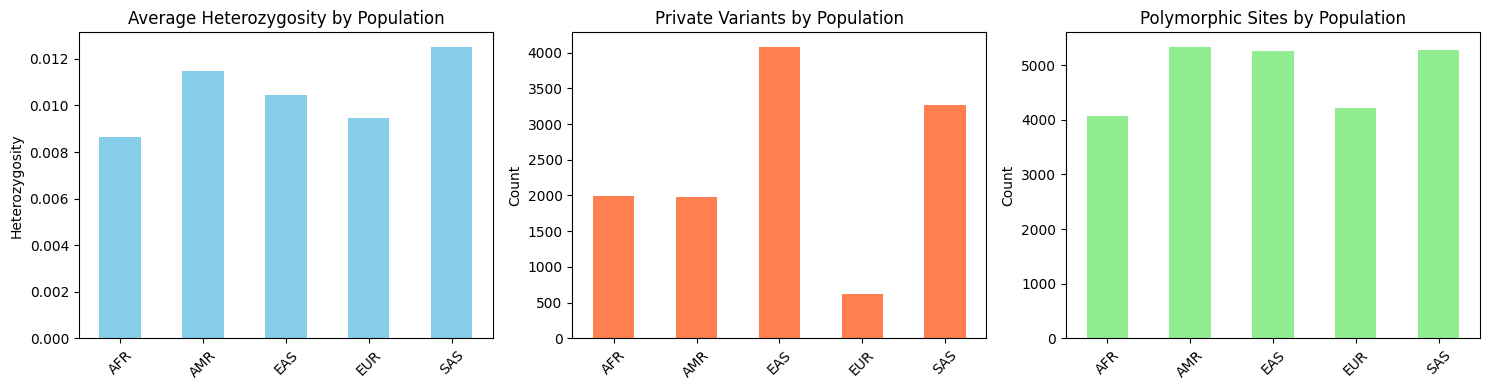

In [4]:
# ============================================================================
# 1. HAPLOGROUP ANALYSIS (Simplified approach)
# ============================================================================
print("\n1. HAPLOGROUP ANALYSIS")
print("-"*80)


def identify_major_lineages(df):
    """
    Simplified lineage identification based on allele frequency patterns
    Real haplogroup calling requires specific Y-SNP databases
    """
    results = {}
    
    for pop in pop_cols:
        af = df[pop].values
        
        # Calculate diversity metrics
        heterozygosity = 2 * af * (1 - af)
        avg_het = np.mean(heterozygosity)
        
        # Number of private variants (present in this pop only)
        private_variants = np.sum((df[pop] > 0.01) & 
                                  (df[[c for c in pop_cols if c != pop]].max(axis=1) < 0.01))
        
        results[pop] = {
            'avg_heterozygosity': avg_het,
            'private_variants': private_variants,
            'n_polymorphic': np.sum(af > 0.01)
        }
    
    return pd.DataFrame(results).T

haplogroup_metrics = identify_major_lineages(df_af)
print("\nPopulation Diversity Metrics:")
print(haplogroup_metrics)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
haplogroup_metrics['avg_heterozygosity'].plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Average Heterozygosity by Population')
axes[0].set_ylabel('Heterozygosity')
axes[0].tick_params(axis='x', rotation=45)

haplogroup_metrics['private_variants'].plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Private Variants by Population')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

haplogroup_metrics['n_polymorphic'].plot(kind='bar', ax=axes[2], color='lightgreen')
axes[2].set_title('Polymorphic Sites by Population')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('haplogroup_metrics.png', dpi=300, bbox_inches='tight')
plt.show()



2. POPULATION DIFFERENTIATION
--------------------------------------------------------------------------------

Pairwise FST Matrix:
     AFR  AMR  EAS  EUR  SAS
AFR  0.0  0.0  0.0  0.0  0.0
AMR  0.0  0.0  0.0  0.0  0.0
EAS  0.0  0.0  0.0  0.0  0.0
EUR  0.0  0.0  0.0  0.0  0.0
SAS  0.0  0.0  0.0  0.0  0.0


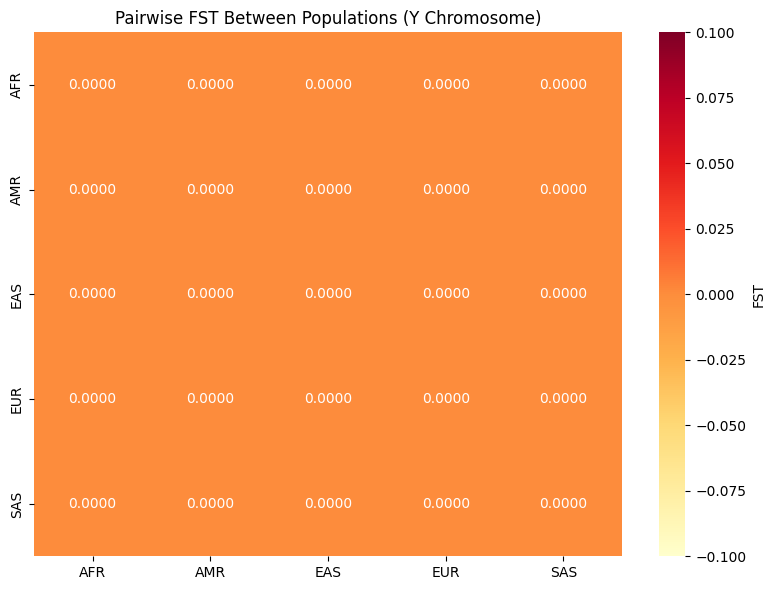


Performing PCA...

Explained variance ratio: PC1=0.322, PC2=0.283


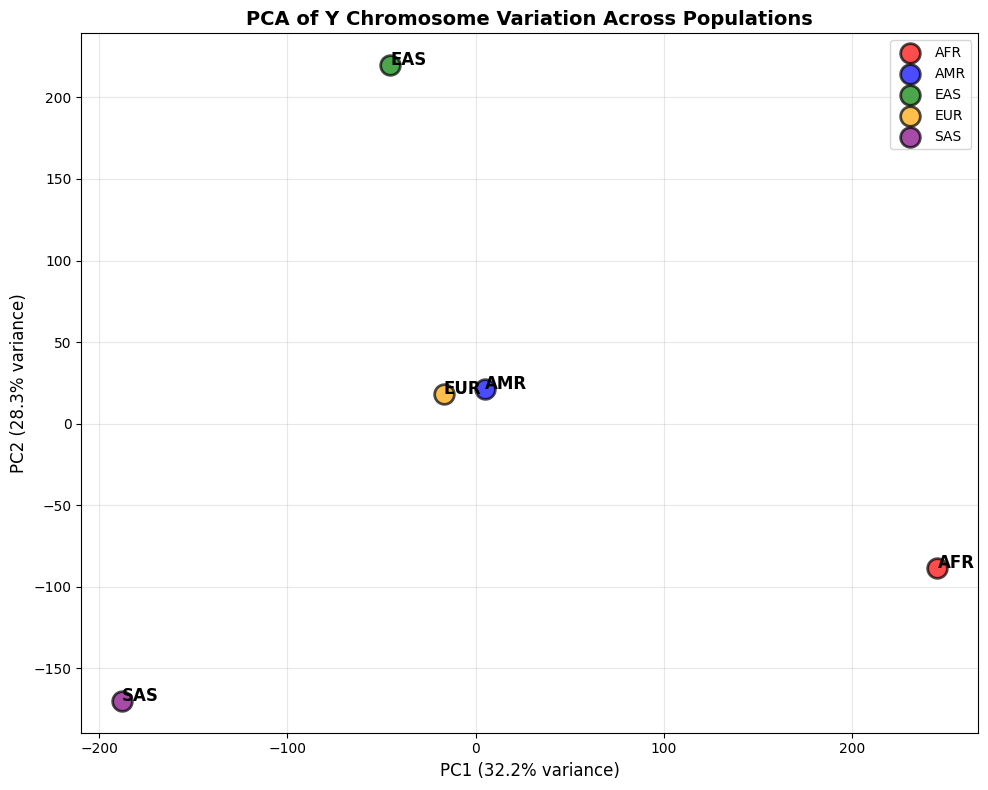

In [5]:
# ============================================================================
# 2. POPULATION DIFFERENTIATION (FST & PCA)
# ============================================================================
print("\n2. POPULATION DIFFERENTIATION")
print("-"*80)

# Calculate FST between all population pairs
def calculate_fst(p1, p2):
    """
    Calculate Weir & Cockerham FST between two populations
    """
    # Remove missing data
    mask = ~(np.isnan(p1) | np.isnan(p2))
    p1 = p1[mask]
    p2 = p2[mask]
    
    # Expected heterozygosity
    ht = 2 * np.mean([p1, p2], axis=0) * (1 - np.mean([p1, p2], axis=0))
    hs = np.mean([2 * p1 * (1 - p1), 2 * p2 * (1 - p2)], axis=0)
    
    # FST
    fst = np.mean((ht - hs) / ht)
    return max(0, fst)  # FST can't be negative

# Calculate pairwise FST
fst_matrix = pd.DataFrame(index=pop_cols, columns=pop_cols, dtype=float)

for pop1 in pop_cols:
    for pop2 in pop_cols:
        if pop1 == pop2:
            fst_matrix.loc[pop1, pop2] = 0
        else:
            fst_matrix.loc[pop1, pop2] = calculate_fst(
                df_af[pop1].values, 
                df_af[pop2].values
            )

print("\nPairwise FST Matrix:")
print(fst_matrix)

# Visualize FST
plt.figure(figsize=(8, 6))
sns.heatmap(fst_matrix.astype(float), annot=True, fmt='.4f', 
            cmap='YlOrRd', cbar_kws={'label': 'FST'})
plt.title('Pairwise FST Between Populations (Y Chromosome)')
plt.tight_layout()
plt.savefig('fst_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# PCA Analysis
print("\nPerforming PCA...")
# Prepare data: transpose so populations are rows
X = df_af[pop_cols].T.values

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

# Create PCA dataframe
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'], index=pop_cols)
pca_df['Population'] = pop_cols

print(f"\nExplained variance ratio: PC1={pca.explained_variance_ratio_[0]:.3f}, "
      f"PC2={pca.explained_variance_ratio_[1]:.3f}")

# Plot PCA
plt.figure(figsize=(10, 8))
colors = {'AFR': 'red', 'AMR': 'blue', 'EAS': 'green', 'EUR': 'orange', 'SAS': 'purple'}

for pop in pop_cols:
    plt.scatter(pca_df.loc[pop, 'PC1'], pca_df.loc[pop, 'PC2'], 
                c=colors[pop], s=200, label=pop, alpha=0.7, edgecolors='black', linewidth=2)
    plt.annotate(pop, (pca_df.loc[pop, 'PC1'], pca_df.loc[pop, 'PC2']), 
                fontsize=12, fontweight='bold')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
plt.title('PCA of Y Chromosome Variation Across Populations', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pca_plot.png', dpi=300, bbox_inches='tight')
plt.show()



3. RARE VS COMMON VARIANTS ANALYSIS
--------------------------------------------------------------------------------

Variant Classification by Population:
     Rare (< 1%)  Low Frequency (1-5%)  Common (> 5%)
AFR        56728                  2467           1594
AMR        55456                  3767           1566
EAS        55530                  2950           2309
EUR        56565                  2610           1614
SAS        55511                  2688           2590


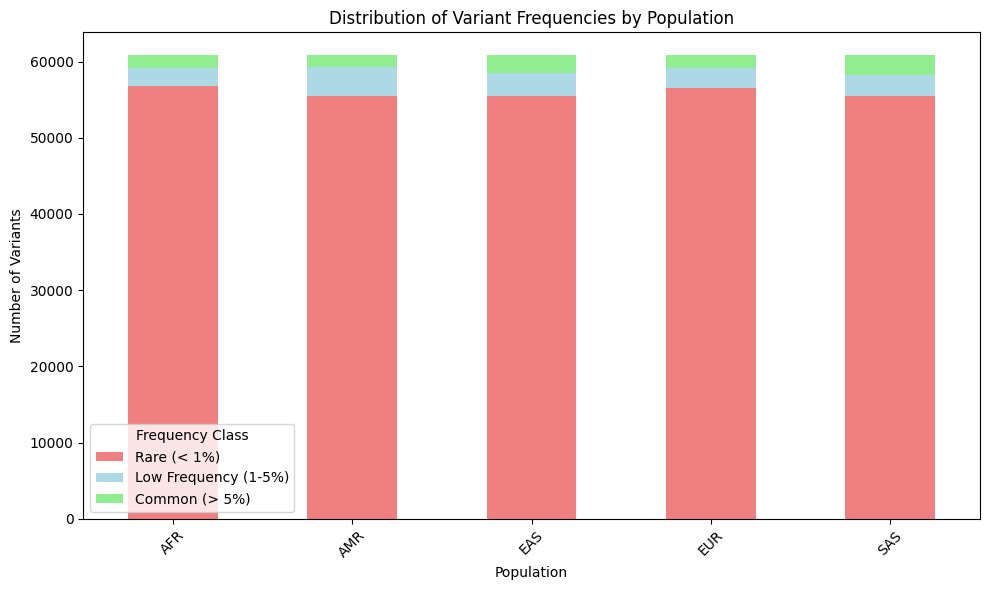

In [6]:
# ============================================================================
# 3. RARE VS COMMON VARIANTS
# ============================================================================
print("\n3. RARE VS COMMON VARIANTS ANALYSIS")
print("-"*80)

def classify_variants(af):
    """Classify variants by allele frequency"""
    if af < 0.01:
        return 'Rare (< 1%)'
    elif af < 0.05:
        return 'Low Frequency (1-5%)'
    else:
        return 'Common (> 5%)'

# Count variants by category for each population
variant_classes = {}

for pop in pop_cols:
    classes = df_af[pop].apply(classify_variants).value_counts()
    variant_classes[pop] = classes

variant_class_df = pd.DataFrame(variant_classes).T.fillna(0)
print("\nVariant Classification by Population:")
print(variant_class_df)

# Visualize
variant_class_df.plot(kind='bar', stacked=True, figsize=(10, 6),
                      color=['lightcoral', 'lightblue', 'lightgreen'])
plt.title('Distribution of Variant Frequencies by Population')
plt.xlabel('Population')
plt.ylabel('Number of Variants')
plt.legend(title='Frequency Class')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('variant_frequency_distribution.png', dpi=300, bbox_inches='tight')
plt.show()



4. SELECTION ANALYSIS
--------------------------------------------------------------------------------
AFR: Tajima's D = -0.288
AMR: Tajima's D = -0.235
EAS: Tajima's D = -0.257
EUR: Tajima's D = -0.242
SAS: Tajima's D = -0.259


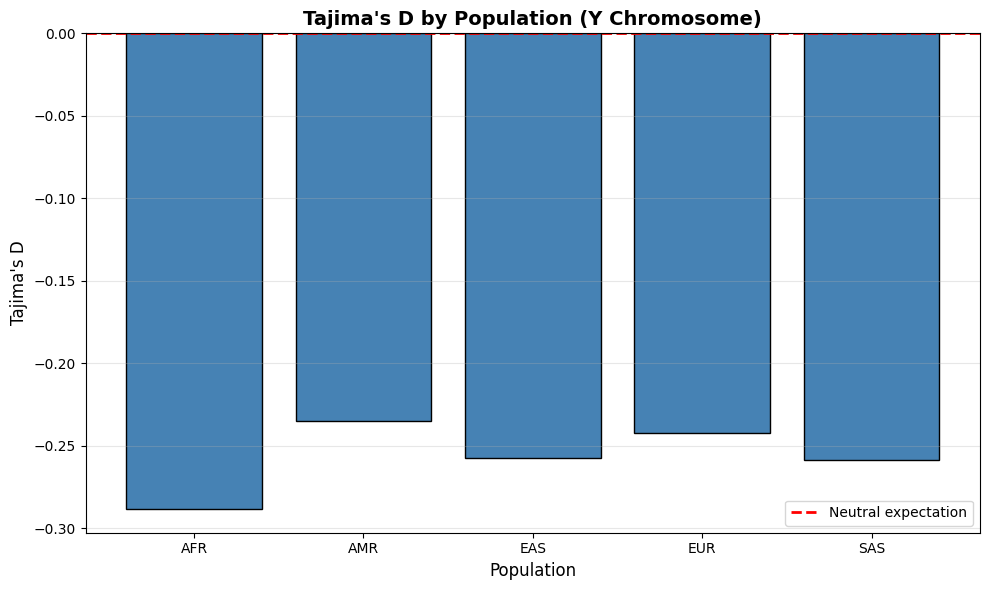


Variants with Large Frequency Differences Between Populations:
            POS          ID REF ALT        AF
17559  14197867   rs4141886   A   G  0.287105
23081  15203676  rs73621768   G   A  0.287105
31044  16863259  rs73621796   G   C  0.287105
40671  18776629   rs9786832   A   T  0.287105
20354  14636530   rs9786220   A   T  0.311224
22580  15095345   rs9785670   G   A  0.313263
218     2707859  rs73625100   G   C  0.311436
293     2722506   rs2075640   A   G  0.312247
451     2756471   rs9785784   T   A  0.311436
930     2863665   rs7892924   G   A  0.311436


In [7]:
# ============================================================================
# 4. SELECTION ANALYSIS (Simplified)
# ============================================================================
print("\n4. SELECTION ANALYSIS")
print("-"*80)

# Calculate Tajima's D for each population (simplified version)
def calculate_tajimas_d(af, n_samples=250):
    """
    Simplified Tajima's D calculation
    Positive D = balancing selection
    Negative D = directional selection
    """
    af = af[(af > 0) & (af < 1)]  # Remove fixed alleles
    
    if len(af) < 2:
        return np.nan
    
    # Number of segregating sites
    S = len(af)
    
    # Average pairwise differences (π)
    pi = np.mean(2 * af * (1 - af)) * S
    
    # Expected value under neutrality
    a1 = sum(1/i for i in range(1, n_samples))
    theta_w = S / a1
    
    # Tajima's D
    if theta_w == 0:
        return np.nan
    
    # Simplified variance calculation
    e1 = (n_samples + 1) / (3 * (n_samples - 1))
    e2 = 2 * (n_samples**2 + n_samples + 3) / (9 * n_samples * (n_samples - 1))
    var_d = e1 * S + e2 * S * (S - 1)
    
    if var_d <= 0:
        return np.nan
    
    D = (pi - theta_w) / np.sqrt(var_d)
    return D

tajimas_d = {}
for pop in pop_cols:
    D = calculate_tajimas_d(df_af[pop].values)
    tajimas_d[pop] = D
    print(f"{pop}: Tajima's D = {D:.3f}" if not np.isnan(D) else f"{pop}: Tajima's D = NA")

# Visualize
plt.figure(figsize=(10, 6))
valid_d = {k: v for k, v in tajimas_d.items() if not np.isnan(v)}
plt.bar(valid_d.keys(), valid_d.values(), color='steelblue', edgecolor='black')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Neutral expectation')
plt.xlabel('Population', fontsize=12)
plt.ylabel("Tajima's D", fontsize=12)
plt.title("Tajima's D by Population (Y Chromosome)", fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('tajimas_d.png', dpi=300, bbox_inches='tight')
plt.show()

# Find variants with large frequency differences (potential selection)
print("\nVariants with Large Frequency Differences Between Populations:")
max_diff = df_af[pop_cols].max(axis=1) - df_af[pop_cols].min(axis=1)
high_diff_variants = df_variants.iloc[max_diff.nlargest(10).index]
print(high_diff_variants[['POS', 'ID', 'REF', 'ALT', 'AF']])



5. GEOGRAPHIC PATTERNS
--------------------------------------------------------------------------------


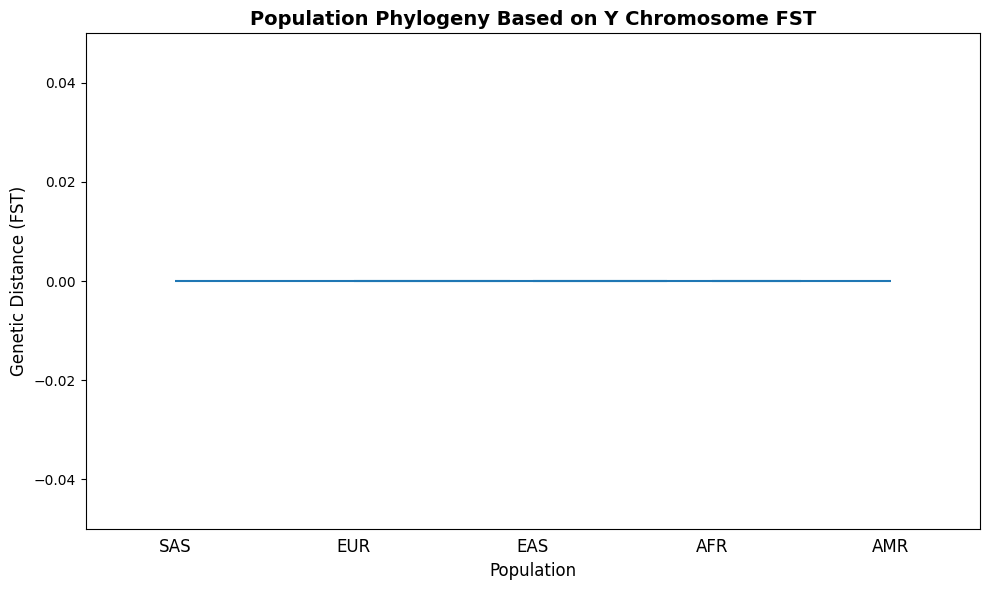

In [8]:
# ============================================================================
# 5. GEOGRAPHIC PATTERNS (Distance Matrix & Dendrogram)
# ============================================================================
print("\n5. GEOGRAPHIC PATTERNS")
print("-"*80)

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

# Convert FST to distance matrix
fst_dist = fst_matrix.astype(float).values

# Hierarchical clustering
linkage_matrix = linkage(squareform(fst_dist), method='average')

# Plot dendrogram
plt.figure(figsize=(10, 6))
dendrogram(linkage_matrix, labels=pop_cols, leaf_font_size=12)
plt.title('Population Phylogeny Based on Y Chromosome FST', fontsize=14, fontweight='bold')
plt.xlabel('Population', fontsize=12)
plt.ylabel('Genetic Distance (FST)', fontsize=12)
plt.tight_layout()
plt.savefig('population_dendrogram.png', dpi=300, bbox_inches='tight')
plt.show()



6. FUNCTIONAL ANNOTATION (Position-based)
--------------------------------------------------------------------------------

Variants by Genomic Region:
Gene
Intergenic    60537
AMELY           251
SRY               1
Name: count, dtype: int64


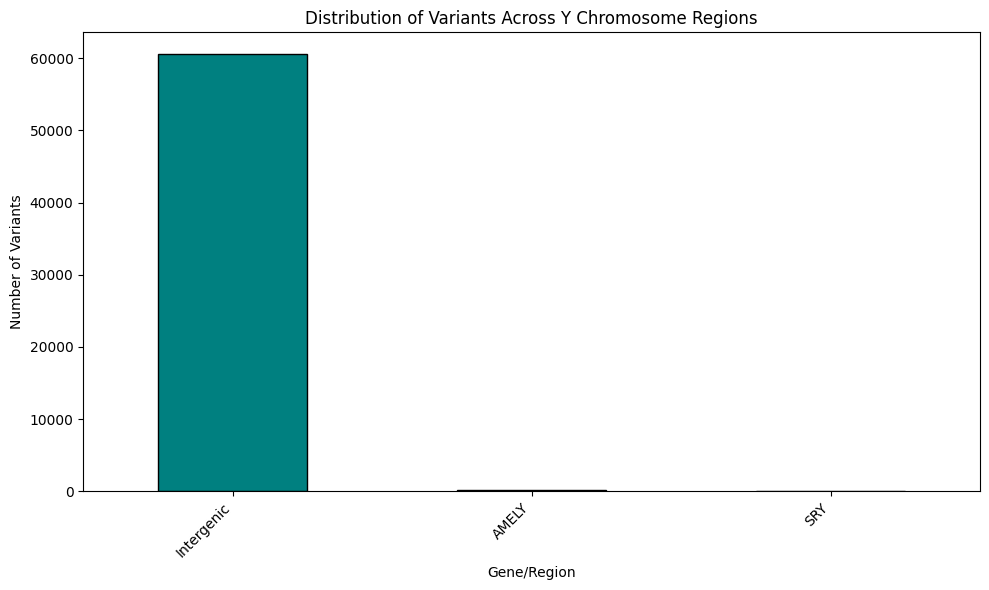


Total functional variants in genes: 252

Top functional variants:
          POS   Gene REF ALT        AF
574   2787129    SRY   C   G  0.000811
2501  6865884  AMELY   A   G  0.000811
2502  6866051  AMELY   C   T  0.000000
2503  6866201  AMELY   G   A  0.002433
2504  6866757  AMELY   G   A  0.000811
2505  6866836  AMELY   G   T  0.000811
2506  6867209  AMELY   C   A  0.000811
2507  6867402  AMELY   C   T  0.001622
2508  6867406  AMELY   G   A  0.000811
2509  6867589  AMELY   C   T  0.021898


In [9]:
# ============================================================================
# 6. FUNCTIONAL ANNOTATION (Simplified)
# ============================================================================
print("\n6. FUNCTIONAL ANNOTATION (Position-based)")
print("-"*80)

# Y chromosome gene regions (simplified - major genes)
# Real annotation would use VEP, ANNOVAR, or similar tools
y_genes = {
    'SRY': (2786855, 2787699),           # Sex-determining region
    'AMELY': (6865884, 6911753),          # Amelogenin
    'TSPY': (9211381, 9260621),          # Testis-specific protein
    'DAZ': (25602393, 25734824),         # Deleted in azoospermia
}

def annotate_position(pos):
    """Check if variant is in a known gene"""
    for gene, (start, end) in y_genes.items():
        if start <= pos <= end:
            return gene
    return 'Intergenic'

if 'POS' in df_variants.columns:
    df_variants['Gene'] = df_variants['POS'].apply(annotate_position)
    
    gene_counts = df_variants['Gene'].value_counts()
    print("\nVariants by Genomic Region:")
    print(gene_counts)
    
    # Visualize
    plt.figure(figsize=(10, 6))
    gene_counts.plot(kind='bar', color='teal', edgecolor='black')
    plt.title('Distribution of Variants Across Y Chromosome Regions')
    plt.xlabel('Gene/Region')
    plt.ylabel('Number of Variants')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('functional_annotation.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Identify functional variants in genes
    functional_variants = df_variants[df_variants['Gene'] != 'Intergenic']
    print(f"\nTotal functional variants in genes: {len(functional_variants)}")
    if len(functional_variants) > 0:
        print("\nTop functional variants:")
        print(functional_variants.head(10)[['POS', 'Gene', 'REF', 'ALT', 'AF']])


In [11]:
# ============================================================================
# SUMMARY REPORT 
# ============================================================================
print("\n" + "="*80)
print("ANALYSIS SUMMARY")
print("="*80)

# Get non-diagonal FST values (exclude self-comparisons)
fst_values = []
fst_pairs = []
for i, pop1 in enumerate(pop_cols):
    for j, pop2 in enumerate(pop_cols):
        if i < j:  # Only upper triangle
            fst_values.append(float(fst_matrix.loc[pop1, pop2]))
            fst_pairs.append((pop1, pop2))

# Find max and min FST
max_fst_idx = np.argmax(fst_values)
min_fst_idx = np.argmin(fst_values)

# Check if functional variants exist
has_functional = 'Gene' in df_variants.columns
if has_functional:
    functional_variants = df_variants[df_variants['Gene'] != 'Intergenic']
    n_functional = len(functional_variants)
else:
    n_functional = 0

summary = f"""
1. HAPLOGROUP METRICS:
   - Highest heterozygosity: {haplogroup_metrics['avg_heterozygosity'].idxmax()}
   - Most private variants: {haplogroup_metrics['private_variants'].idxmax()}

2. POPULATION DIFFERENTIATION:
   - Most differentiated populations: {fst_pairs[max_fst_idx][0]} vs {fst_pairs[max_fst_idx][1]}
   - FST value: {fst_values[max_fst_idx]:.4f}
   - Least differentiated: {fst_pairs[min_fst_idx][0]} vs {fst_pairs[min_fst_idx][1]}
   - FST value: {fst_values[min_fst_idx]:.4f}

3. VARIANT FREQUENCY:
   - Total rare variants: {variant_class_df['Rare (< 1%)'].sum():.0f}
   - Total common variants: {variant_class_df['Common (> 5%)'].sum():.0f}

4. SELECTION SIGNALS:
   - Populations showing selection (|D| > 1): {[k for k, v in tajimas_d.items() if not np.isnan(v) and abs(v) > 1]}

5. GEOGRAPHIC PATTERNS:
   - See dendrogram for population relationships
   - PCA explains {pca.explained_variance_ratio_[0]:.1%} + {pca.explained_variance_ratio_[1]:.1%} = {sum(pca.explained_variance_ratio_):.1%} of variance

6. FUNCTIONAL VARIANTS:
   - Variants in genes: {n_functional}
   - Total variants analyzed: {len(df_variants)}
"""

print(summary)

# Save summary to file
with open('analysis_summary.txt', 'w') as f:
    f.write(summary)

print("\nAll plots saved! Files created:")
print("- haplogroup_metrics.png")
print("- fst_heatmap.png")
print("- pca_plot.png")
print("- variant_frequency_distribution.png")
print("- tajimas_d.png")
print("- population_dendrogram.png")
if has_functional:
    print("- functional_annotation.png")
print("- analysis_summary.txt")
print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)


ANALYSIS SUMMARY

1. HAPLOGROUP METRICS:
   - Highest heterozygosity: SAS
   - Most private variants: EAS

2. POPULATION DIFFERENTIATION:
   - Most differentiated populations: AFR vs AMR
   - FST value: 0.0000
   - Least differentiated: AFR vs AMR
   - FST value: 0.0000

3. VARIANT FREQUENCY:
   - Total rare variants: 279790
   - Total common variants: 9673

4. SELECTION SIGNALS:
   - Populations showing selection (|D| > 1): []

5. GEOGRAPHIC PATTERNS:
   - See dendrogram for population relationships
   - PCA explains 32.2% + 28.3% = 60.5% of variance

6. FUNCTIONAL VARIANTS:
   - Variants in genes: 252
   - Total variants analyzed: 60789


All plots saved! Files created:
- haplogroup_metrics.png
- fst_heatmap.png
- pca_plot.png
- variant_frequency_distribution.png
- tajimas_d.png
- population_dendrogram.png
- functional_annotation.png
- analysis_summary.txt

ANALYSIS COMPLETE!
